In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import yfinance as yf

from datetime import datetime

In [15]:
ticker = "AAPL"

start_date = "2015-01-01"

end_date = datetime.today().strftime("%Y-%m-%d")

prices = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

# Αν το yfinance επιστρέψει MultiIndex columns,
# κράτα μόνο το πρώτο επίπεδο (Open, High, Low, Close, Volume)
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)

print(prices.columns)

[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [16]:
df = prices.copy()

df = df[["Close"]]

df.head()

Price,Close
Date,
2015-01-02,24.192602
2015-01-05,23.511061
2015-01-06,23.513268
2015-01-07,23.842987
2015-01-08,24.759085


In [21]:
df["Log_Return"] = np.log(
    df["Close"] /
    df["Close"].shift(1)
)

In [22]:
df["Return"] = df["Close"].pct_change()

In [23]:
df["SMA20"] = df["Close"].rolling(20).mean()

df["SMA50"] = df["Close"].rolling(50).mean()

df["SMA100"] = df["Close"].rolling(100).mean()

df["SMA200"] = df["Close"].rolling(200).mean()

In [24]:
df["EMA20"] = df["Close"].ewm(
    span=20,
    adjust=False
).mean()

In [25]:
df["Momentum10"] = df["Close"] - df["Close"].shift(10)

df["Momentum20"] = df["Close"] - df["Close"].shift(20)

In [26]:
df["Volatility20"] = (
    df["Log_Return"]
    .rolling(20)
    .std()
)

In [27]:
df["RollingMean20"] = (
    df["Log_Return"]
    .rolling(20)
    .mean()
)

In [28]:
df["RollingSkew20"] = (
    df["Log_Return"]
    .rolling(20)
    .skew()
)

In [29]:
df["RollingKurt20"] = (
    df["Log_Return"]
    .rolling(20)
    .kurt()
)

In [30]:
df["Lag1"] = df["Log_Return"].shift(1)

df["Lag2"] = df["Log_Return"].shift(2)

df["Lag5"] = df["Log_Return"].shift(5)

df["Lag10"] = df["Log_Return"].shift(10)

In [31]:
df["Price_SMA20"] = (
    df["Close"] /
    df["SMA20"]
)

df["Price_SMA50"] = (
    df["Close"] /
    df["SMA50"]
)

In [32]:
rolling_std = (
    df["Close"]
    .rolling(20)
    .std()
)

df["UpperBand"] = (
    df["SMA20"] +
    2 * rolling_std
)

df["LowerBand"] = (
    df["SMA20"] -
    2 * rolling_std
)

In [33]:
delta = df["Close"].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df["RSI"] = 100 - (
    100 /
    (1 + rs)
)

In [34]:
ema12 = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema26 = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = ema12 - ema26

df["MACD_Signal"] = (
    df["MACD"]
    .ewm(span=9)
    .mean()
)

In [35]:
df = df.dropna()

df.head()

Price,Close,Log_Return,Return,SMA20,SMA50,SMA100,SMA200,EMA20,Momentum10,Momentum20,...,Lag2,Lag5,Lag10,Price_SMA20,Price_SMA50,UpperBand,LowerBand,RSI,MACD,MACD_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,24.883137,-0.007358,-0.007331,25.046606,25.176153,26.631793,27.035149,25.013353,0.147905,-0.540051,...,-0.014235,0.023645,0.007274,0.993473,0.988361,25.889497,24.203715,45.695046,-0.136604,-0.159600
2015-10-19,25.037760,0.006195,0.006214,25.007615,25.159167,26.588194,27.039375,25.015677,0.212889,-0.779835,...,0.014861,-0.004649,0.003617,1.001205,0.995174,25.768494,24.246735,59.838000,-0.118958,-0.151471
2015-10-20,25.494896,0.018093,0.018258,25.011760,25.132500,26.552512,27.049294,25.061317,0.551258,0.082909,...,-0.007358,0.001701,0.004773,1.019316,1.014419,25.782752,24.240768,62.073745,-0.067310,-0.134639
2015-10-21,25.492657,-0.000088,-0.000088,25.005486,25.133710,26.516227,27.059191,25.102397,0.667786,-0.125488,...,0.006195,-0.014235,-0.004773,1.019483,1.014281,25.757509,24.253462,65.300136,-0.026256,-0.112962
2015-10-22,25.882586,0.015180,0.015296,25.011088,25.134875,26.485136,27.069389,25.176701,1.344553,0.112059,...,0.018093,0.014861,-0.011622,1.034844,1.029748,25.788357,24.233819,67.534311,0.037312,-0.082907


In [36]:
print(df.shape)

df.describe()

(2702, 25)


Price,Close,Log_Return,Return,SMA20,SMA50,SMA100,SMA200,EMA20,Momentum10,Momentum20,...,Lag2,Lag5,Lag10,Price_SMA20,Price_SMA50,UpperBand,LowerBand,RSI,MACD,MACD_Signal
count,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,...,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000,2702.000000
mean,120.483554,0.000958,0.001124,119.467052,117.941362,115.575388,111.119730,119.475872,1.090342,2.075828,...,0.000951,0.000945,0.000937,1.009352,1.023996,126.520976,112.413129,55.747383,0.716559,0.708190
std,80.303197,0.018166,0.018183,79.546733,78.530667,77.104174,74.563291,79.511149,7.627324,10.284380,...,0.018167,0.018157,0.018156,0.042715,0.070007,84.061710,75.185930,18.074251,2.551321,2.377132
min,20.565865,-0.137708,-0.128647,21.366900,21.785643,22.641503,23.152189,21.768503,-51.060211,-50.423584,...,-0.137708,-0.137708,-0.137708,0.813903,0.752544,22.198283,19.375700,3.180134,-10.574204,-8.292115
25%,41.362541,-0.007215,-0.007189,40.808986,40.485371,41.091091,40.270693,40.837767,-1.859190,-2.147455,...,-0.007270,-0.007215,-0.007270,0.982553,0.979998,43.228094,39.159018,42.479683,-0.533360,-0.414772
50%,123.793499,0.001000,0.001001,123.536060,123.470520,121.562512,109.803030,124.035389,0.842672,1.530890,...,0.000994,0.000994,0.000994,1.014082,1.029061,131.209817,116.245308,57.046242,0.505199,0.445614
75%,178.451283,0.010004,0.010054,177.627081,177.109270,179.216635,169.051606,178.180231,4.225845,6.858686,...,0.010004,0.010004,0.009976,1.038140,1.071625,187.900576,167.176006,69.300073,1.989425,1.893297
max,333.739990,0.142618,0.153289,305.517999,302.632416,282.107506,273.880447,311.632975,40.170013,42.588684,...,0.142618,0.142618,0.142618,1.147493,1.281007,339.203655,291.597655,96.163104,10.487955,9.865886


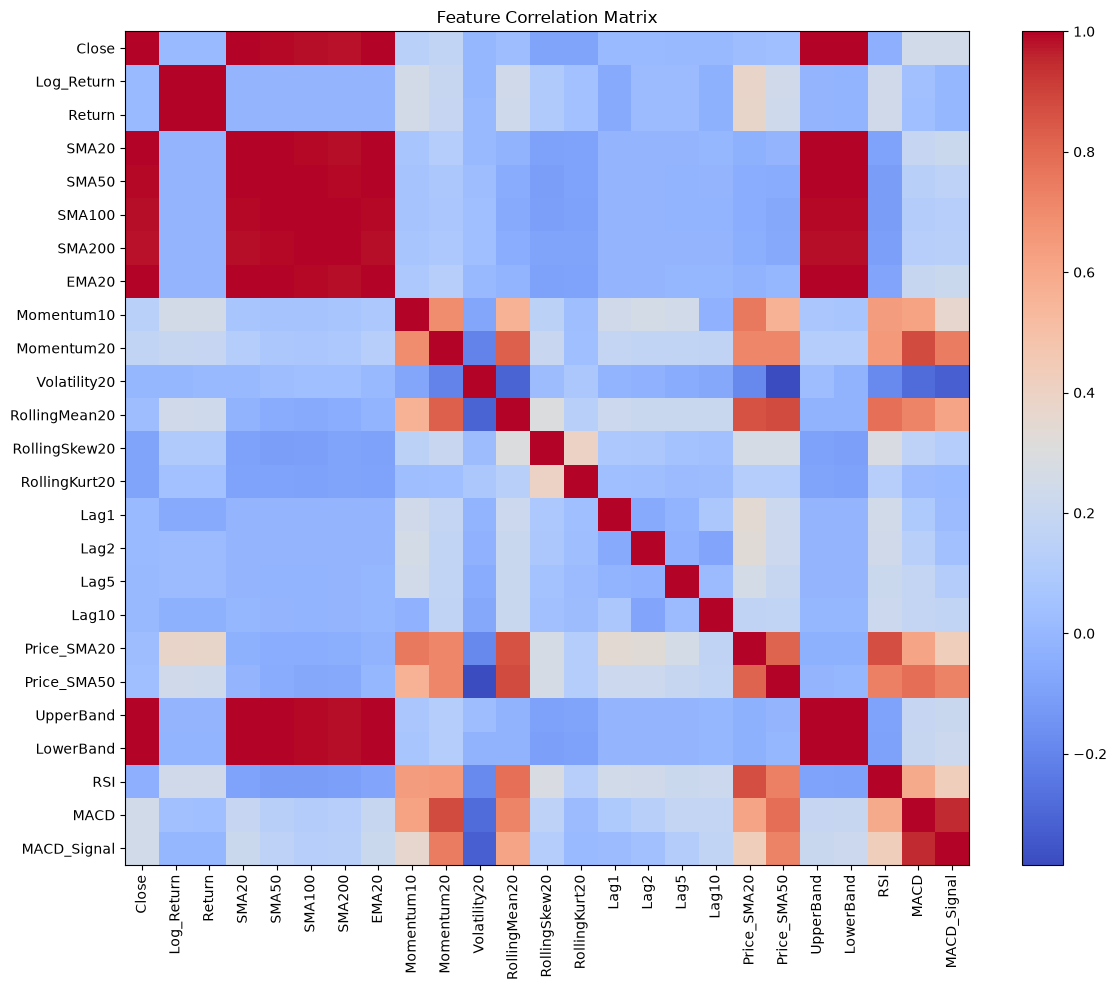

In [37]:
corr = df.corr()

plt.figure(figsize=(12,10))

plt.imshow(
    corr,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Feature Correlation Matrix"
)

plt.tight_layout()

plt.show()

In [38]:
df.tail()

Price,Close,Log_Return,Return,SMA20,SMA50,SMA100,SMA200,EMA20,Momentum10,Momentum20,...,Lag2,Lag5,Lag10,Price_SMA20,Price_SMA50,UpperBand,LowerBand,RSI,MACD,MACD_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-13,317.309998,0.006291,0.006311,299.187001,298.674736,279.561089,272.414623,303.524259,33.529999,21.679993,...,0.008990,0.012973,0.030883,1.060574,1.062393,323.778279,274.595723,63.734764,5.248546,2.576021
2026-07-14,314.859985,-0.007751,-0.007721,300.373500,299.549930,280.068622,272.730931,304.603852,33.119995,23.729980,...,-0.002850,-0.006417,-0.007215,1.048228,1.051110,325.609413,275.137587,63.959800,5.482192,3.157255
2026-07-15,327.500000,0.039360,0.040145,301.927499,300.502288,280.740221,273.087705,306.784438,38.140015,31.079987,...,0.006291,0.008749,0.026687,1.084697,1.089842,329.825669,274.029330,70.232778,6.611093,3.848023
2026-07-16,333.260010,0.017435,0.017588,303.628500,301.635984,281.429456,273.480308,309.305921,38.880005,34.020020,...,-0.007751,0.008990,0.017200,1.097591,1.104842,334.793926,272.463075,89.861421,7.879707,4.654360
2026-07-17,333.739990,0.001439,0.001440,305.517999,302.632416,282.107506,273.880447,311.632975,25.109985,37.789978,...,0.039360,-0.002850,0.047272,1.092374,1.102790,339.203655,271.832343,88.585091,8.822128,5.487913


In [39]:
df.shape

(2702, 25)

In [45]:
df.to_csv(
    "../data/features.csv"
)

print("saved")

saved


In [46]:
import os

print(
    os.listdir()
)

['01_data_engine.ipynb', '02_feature_engineering.ipynb', '03_arima_model.ipynb']
